In [3]:
# =========================
# CELL A: SET PATHS
# =========================

# ---- NI TTL folder ----
ni_folder = r"xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx" ##############################################################

# ---- Phy (Kilosort output) ----
phy_path = r"xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx" ####################################################

print("NI folder:")
print(ni_folder)

print("\nPhy path:")
print(phy_path)

NI folder:
D:\Kevin\2026-03-05_09-27-03\Record Node 106\experiment2\recording1\events\NI-DAQmx-105.PXIe-6341\TTL

Phy path:
D:\Kevin\2026-03-05_09-27-03\Record Node 101\experiment2\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4


✅ Units loaded: 192

💾 Saved summary to: D:\Kevin\2026-03-05_09-27-03\Record Node 101\experiment2\recording1\continuous\Neuropix-PXI-100.ProbeA\burst_analysis_summary.xlsx

Unit 253
  spikes: 58955
  bursts: 1
  burst rate: 0.000 Hz
  % spikes in bursts: 0.00%

Unit 332
  spikes: 12759
  bursts: 114
  burst rate: 0.031 Hz
  % spikes in bursts: 1.80%


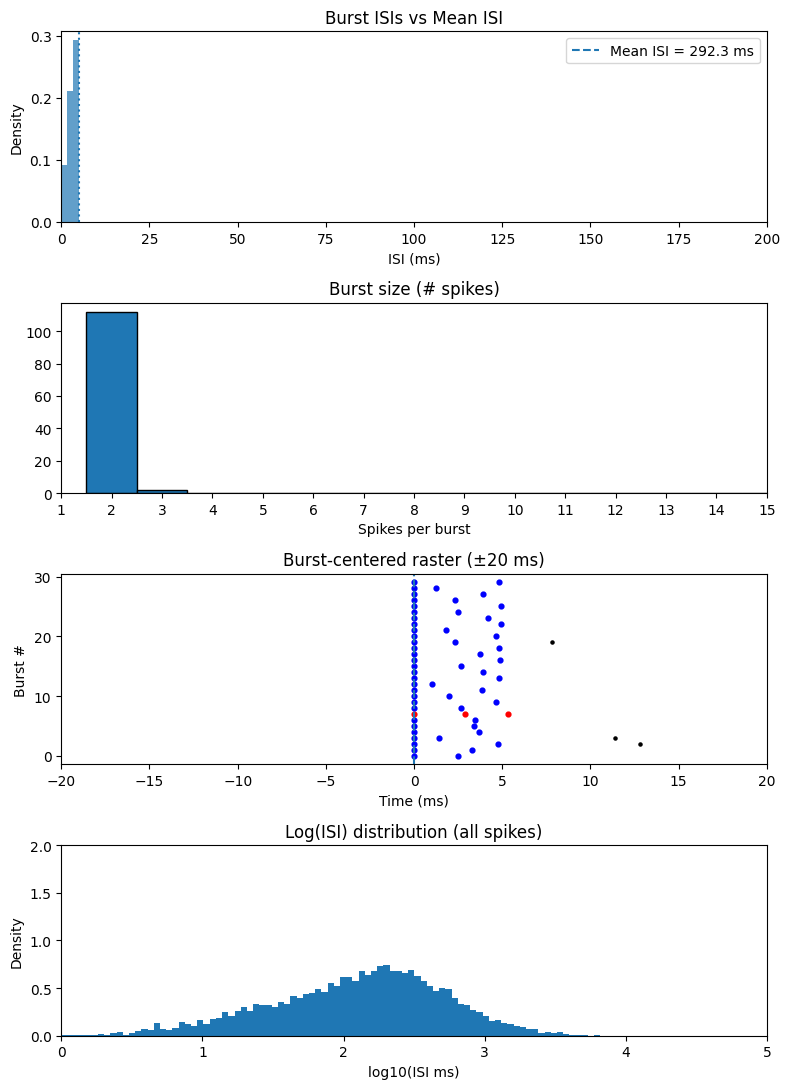


Unit 306
  spikes: 72664
  bursts: 318
  burst rate: 0.085 Hz
  % spikes in bursts: 0.92%


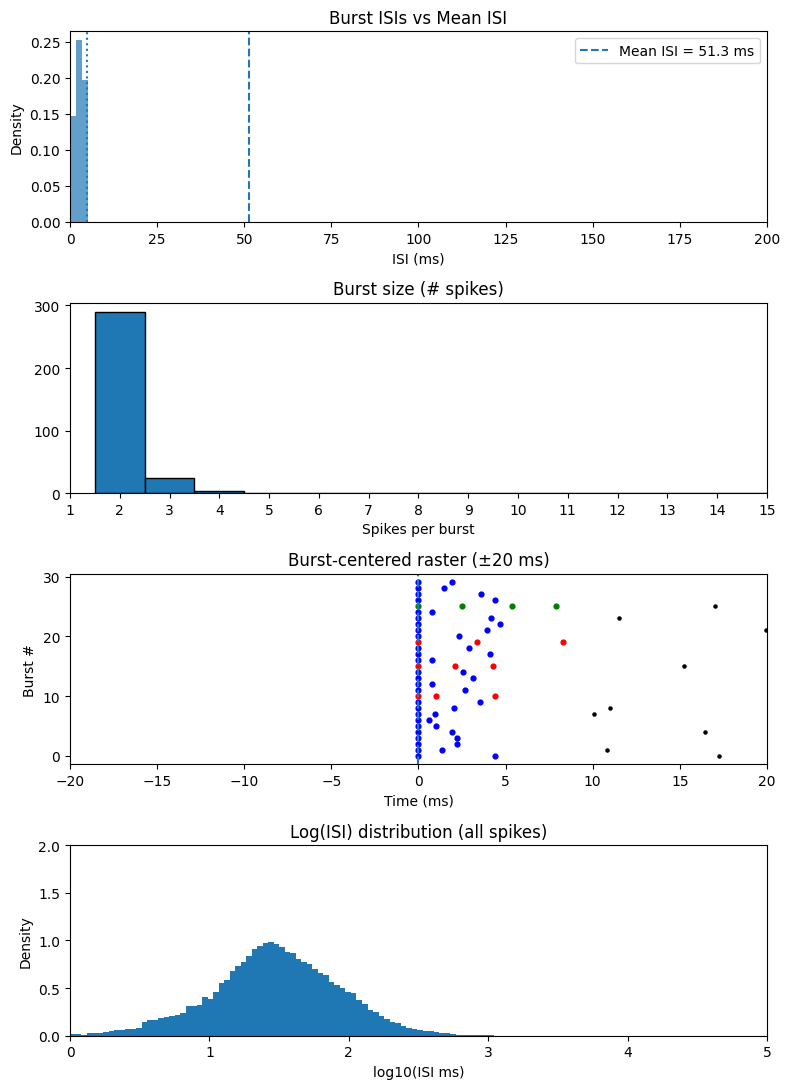


Unit 466
  spikes: 84326
  bursts: 488
  burst rate: 0.131 Hz
  % spikes in bursts: 1.25%


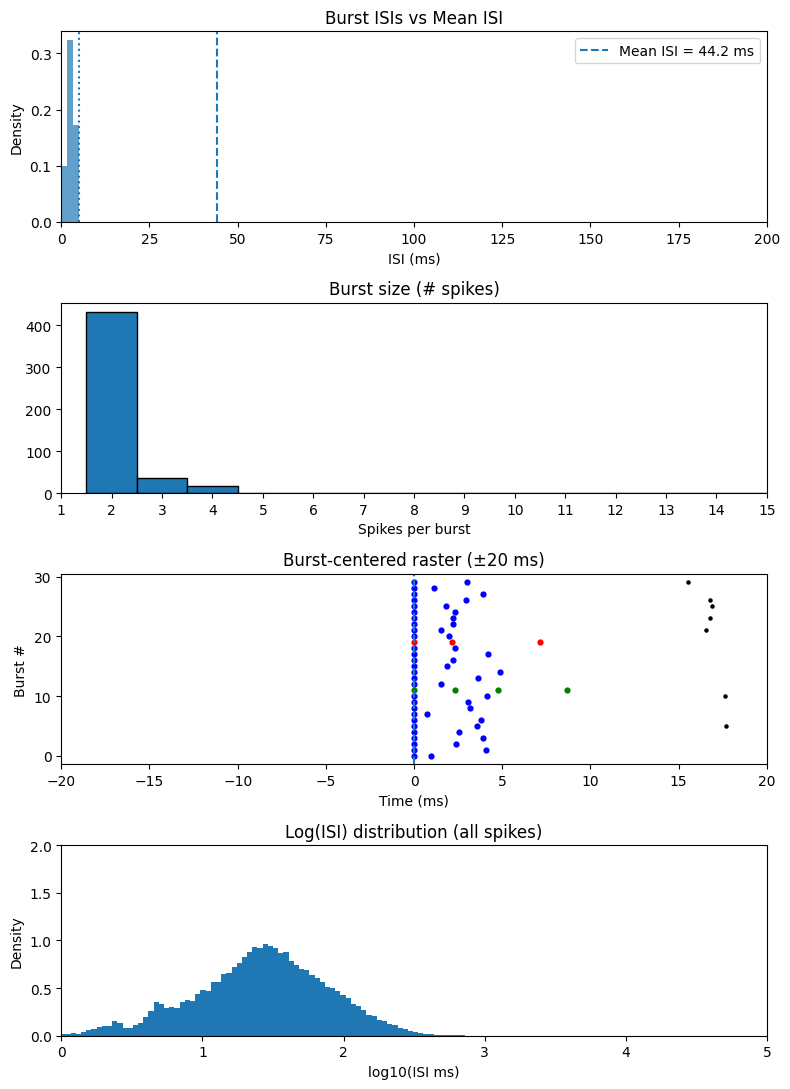


Unit 74
  spikes: 18832
  bursts: 705
  burst rate: 0.189 Hz
  % spikes in bursts: 9.04%


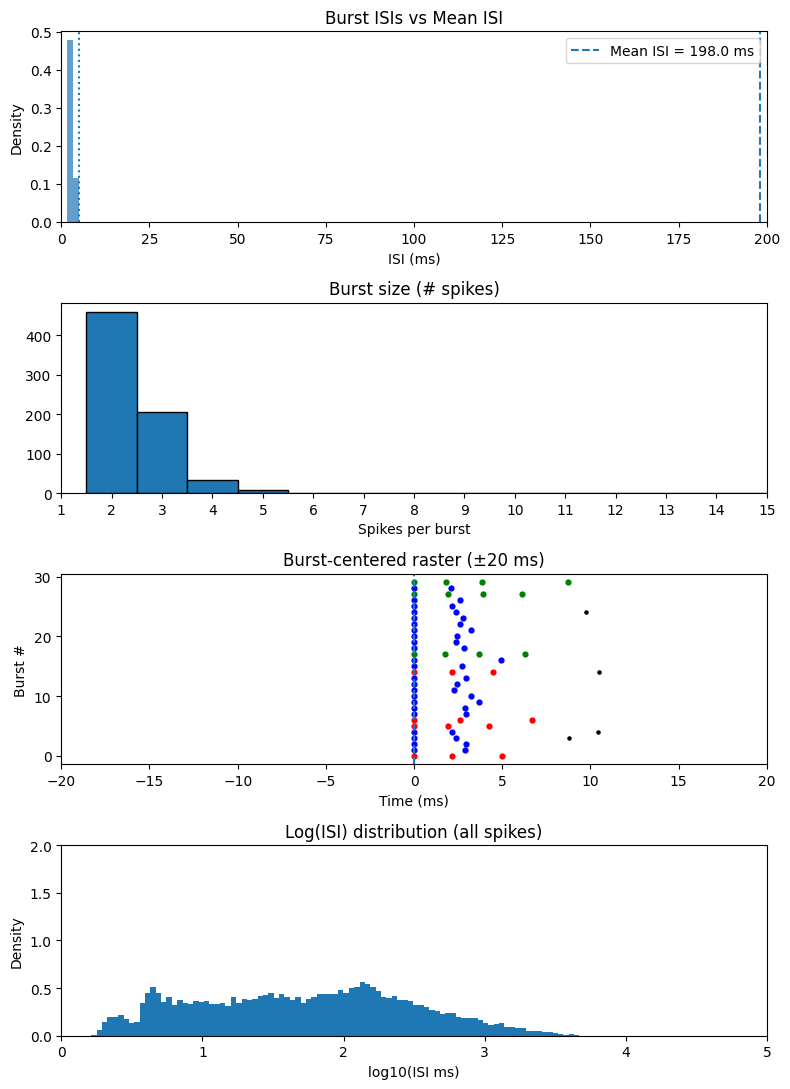


Unit 224
  spikes: 21252
  bursts: 401
  burst rate: 0.108 Hz
  % spikes in bursts: 4.78%


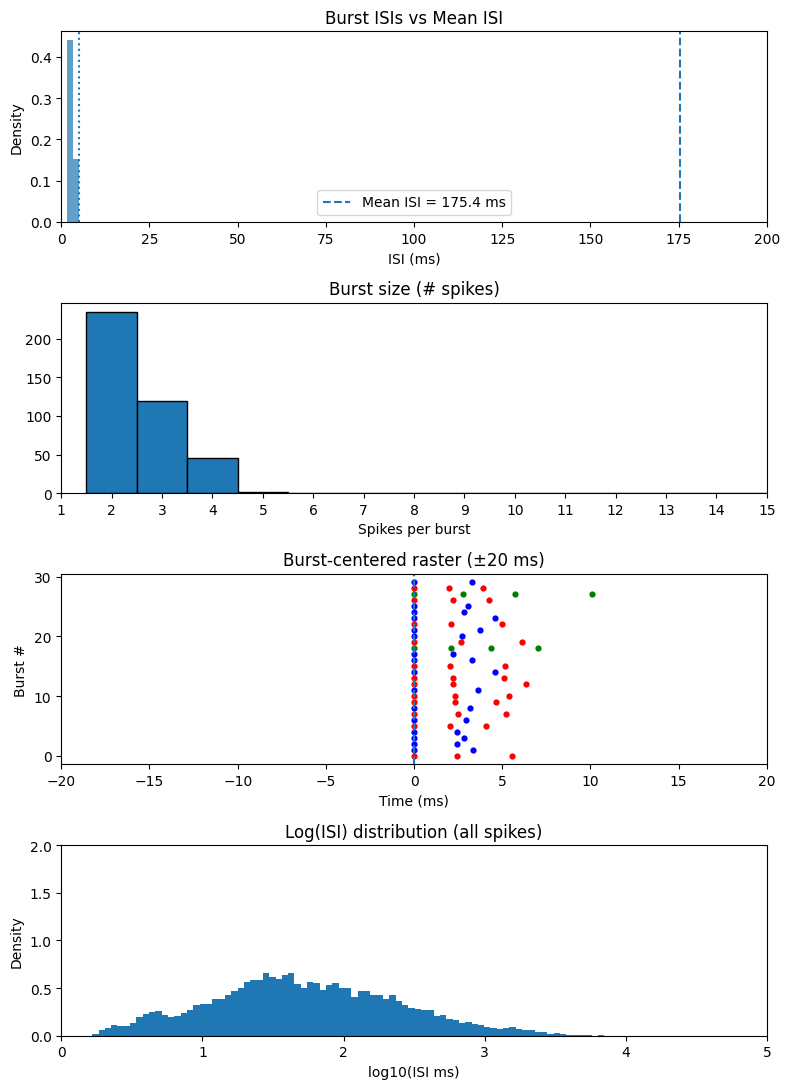


Unit 363
  spikes: 27250
  bursts: 11
  burst rate: 0.003 Hz
  % spikes in bursts: 0.12%


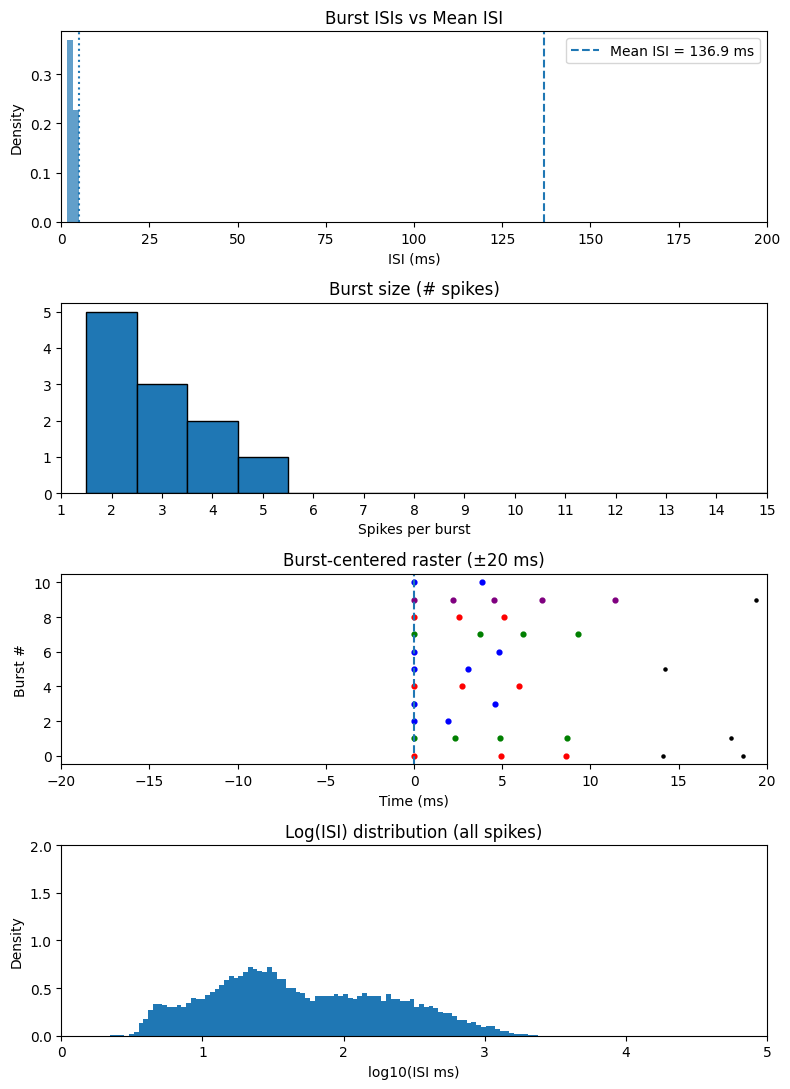


Unit 66
  spikes: 54591
  bursts: 340
  burst rate: 0.091 Hz
  % spikes in bursts: 1.69%


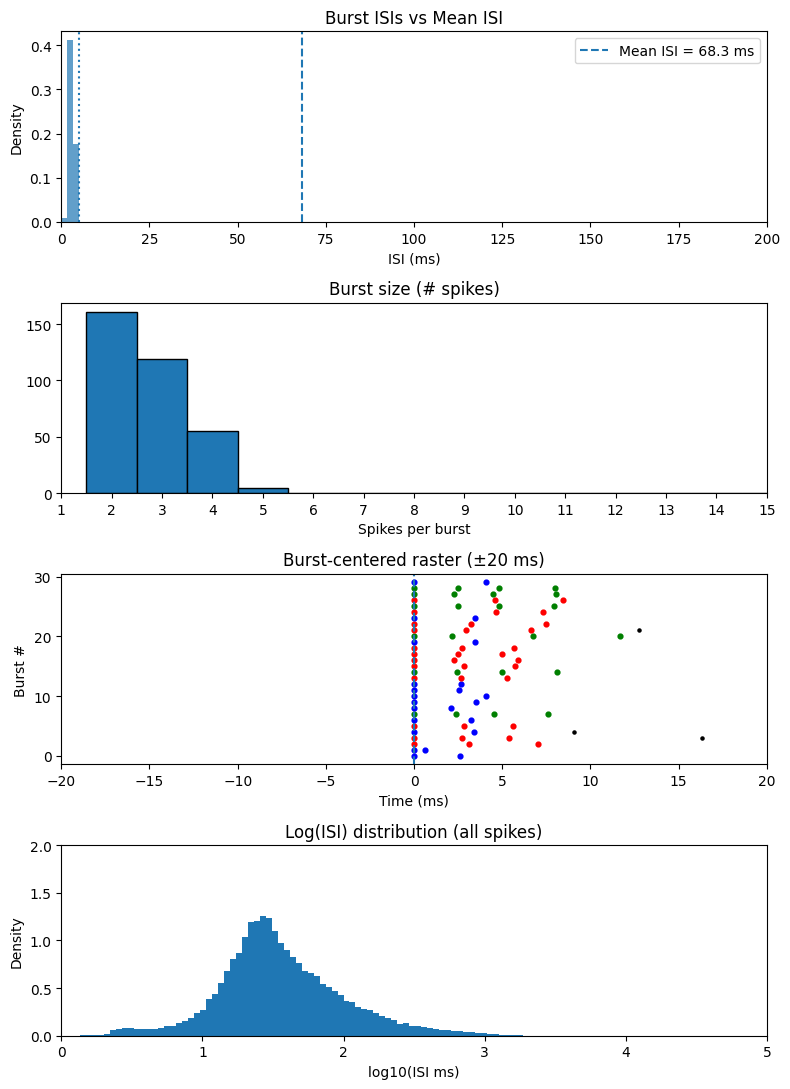


Unit 172
  spikes: 39645
  bursts: 439
  burst rate: 0.118 Hz
  % spikes in bursts: 2.70%


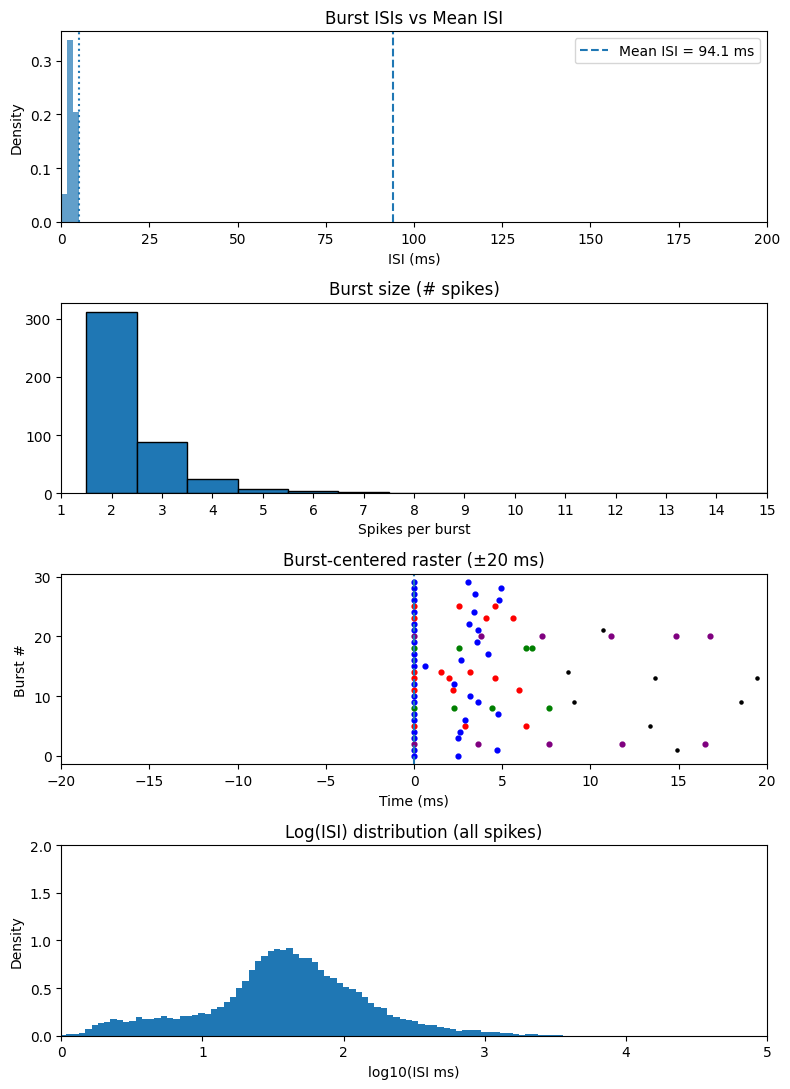


Unit 417
  spikes: 51276
  bursts: 229
  burst rate: 0.061 Hz
  % spikes in bursts: 1.09%


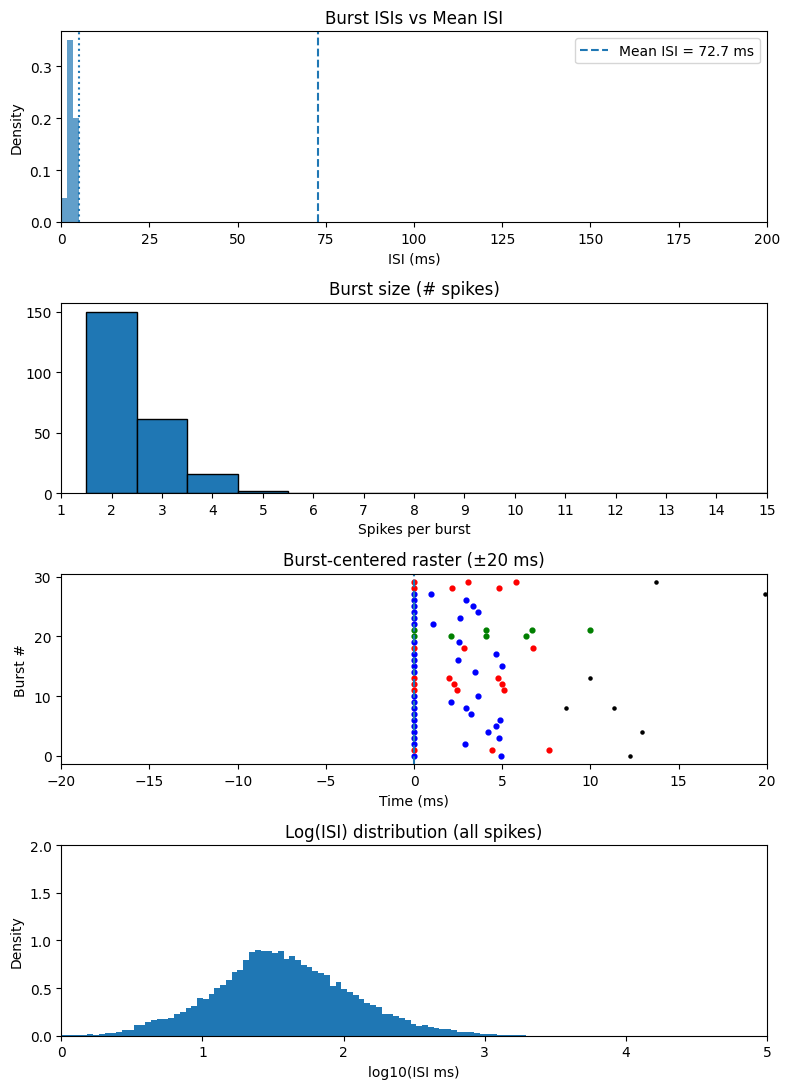

In [4]:
# =========================
# 🔧 USER-EDITABLE PARAMETERS
# =========================

# ---- Burst detection ----
MIN_QUIET = 0.100
MAX_ISI = 0.005
MIN_SPIKES = 2

# ---- Unit filtering ----
MIN_SPIKES_PER_UNIT = 50
MIN_BURSTS_TO_PLOT = 3

# ---- Sampling for plots ----
N_PLOT_UNITS = 10   # 🔥 NEW: only visualize this many random units

# ---- ISI histogram ----
MAX_ISI_PLOT = 200
ISI_BINS = 120

# ---- Burst size histogram ----
BURST_SIZE_MAX = 15

# ---- Example burst visualization ----
EXAMPLE_BURSTS_TO_PLOT = 30
WINDOW = 0.02

# ---- Log(ISI) plot ----
LOG_ISI_XLIM = (0, 5)
LOG_ISI_YLIM = (0, 2.0)
LOG_ISI_BINS = 100

# ---- OUTPUT ----
import os

OUTPUT_DIR = os.path.abspath(os.path.join(phy_path, ".."))  # one level above Kilosort folder
OUTPUT_XLSX = os.path.join(OUTPUT_DIR, "burst_analysis_summary.xlsx")


#############################################


import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import pandas as pd
import os
import random


# =========================
# 1. LOAD SORTING + CURATION
# =========================
sorting = se.read_phy(phy_path)

cg_path = os.path.join(phy_path, "cluster_group.tsv")
df = pd.read_csv(cg_path, sep="\t")

good_cluster_ids = set(df[df["group"] == "good"]["cluster_id"].values)
unit_ids_all = sorting.get_unit_ids()

good_units = [u for u in unit_ids_all if u in good_cluster_ids]
sorting_good = sorting.select_units(good_units)

unit_ids = sorting_good.get_unit_ids()
sf = sorting_good.get_sampling_frequency()

print("✅ Units loaded:", len(unit_ids))


# =========================
# 2. BURST DETECTOR
# =========================
def detect_bursts(spike_times, min_quiet, max_isi, min_spikes):

    spike_times = np.asarray(spike_times)
    n = len(spike_times)

    bursts = []
    i = 0

    while i < n - 1:

        if i == 0:
            prev_isi = np.inf
        else:
            prev_isi = spike_times[i] - spike_times[i - 1]

        if prev_isi >= min_quiet:

            burst_spikes = [spike_times[i]]
            j = i

            while j < n - 1 and (spike_times[j + 1] - spike_times[j]) <= max_isi:
                burst_spikes.append(spike_times[j + 1])
                j += 1

            if len(burst_spikes) >= min_spikes:
                bursts.append({
                    "start": burst_spikes[0],
                    "end": burst_spikes[-1],
                    "n_spikes": len(burst_spikes),
                    "spikes": np.array(burst_spikes)
                })
                i = j + 1
                continue

        i += 1

    return bursts


# =========================
# 3. SORT UNITS BY SPIKE COUNT
# =========================
n_spikes_per_unit = np.array([
    len(sorting_good.get_unit_spike_train(u)) for u in unit_ids
])

sorted_units = [unit_ids[i] for i in np.argsort(n_spikes_per_unit)[::-1]]


# =========================
# 🔥 NEW: storage for Excel output
# =========================
results = []


# =========================
# 4. ANALYZE UNITS
# =========================
for unit in sorted_units:

    spike_train = sorting_good.get_unit_spike_train(unit)
    spike_times = spike_train / sf

    if len(spike_times) < MIN_SPIKES_PER_UNIT:
        continue

    bursts = detect_bursts(
        spike_times,
        min_quiet=MIN_QUIET,
        max_isi=MAX_ISI,
        min_spikes=MIN_SPIKES
    )

    # ---- summary stats ----
    n_bursts = len(bursts)
    duration = spike_times[-1] - spike_times[0]
    burst_rate = n_bursts / duration if duration > 0 else 0

    spikes_in_bursts = sum([b["n_spikes"] for b in bursts])
    burst_fraction = spikes_in_bursts / len(spike_times)

    # =========================
    # 🔥 SAVE TO TABLE
    # =========================
    results.append({
        "unit": unit,
        "n_spikes": len(spike_times),
        "n_bursts": n_bursts,
        "burst_rate_hz": burst_rate,
        "burst_fraction": burst_fraction
    })


# =========================
# 🔥 EXPORT TO EXCEL
# =========================
df_out = pd.DataFrame(results)
df_out.to_excel(OUTPUT_XLSX, index=False)

print(f"\n💾 Saved summary to: {OUTPUT_XLSX}")


# =========================
# 5. RANDOM VISUALIZATION SAMPLE
# =========================
plot_units = random.sample(
    [u for u in sorted_units if len(sorting_good.get_unit_spike_train(u)/sf) >= MIN_SPIKES_PER_UNIT],
    min(N_PLOT_UNITS, len(sorted_units))
)


# =========================
# 5. RANDOM VISUALIZATION SAMPLE
# =========================
plot_units = random.sample(
    [u for u in sorted_units
     if len(sorting_good.get_unit_spike_train(u) / sf) >= MIN_SPIKES_PER_UNIT],
    min(N_PLOT_UNITS, len(sorted_units))
)


# =========================
# 6. VISUALIZATION LOOP (RESTORED STYLE)
# =========================
for unit in plot_units:

    spike_train = sorting_good.get_unit_spike_train(unit)
    spike_times = spike_train / sf

    bursts = detect_bursts(
        spike_times,
        min_quiet=MIN_QUIET,
        max_isi=MAX_ISI,
        min_spikes=MIN_SPIKES
    )

    n_bursts = len(bursts)
    duration = spike_times[-1] - spike_times[0]
    burst_rate = n_bursts / duration if duration > 0 else 0

    spikes_in_bursts = sum([b["n_spikes"] for b in bursts])
    burst_fraction = spikes_in_bursts / len(spike_times)

    # =========================
    # PRINT SUMMARY (RESTORED)
    # =========================
    print(f"\nUnit {unit}")
    print(f"  spikes: {len(spike_times)}")
    print(f"  bursts: {n_bursts}")
    print(f"  burst rate: {burst_rate:.3f} Hz")
    print(f"  % spikes in bursts: {burst_fraction:.2%}")

    if n_bursts < MIN_BURSTS_TO_PLOT:
        continue

    # =========================
    # VISUALIZATION
    # =========================
    fig, axes = plt.subplots(4, 1, figsize=(8, 11))
    ax_isi, ax_burst, ax_examples, ax_logisi = axes


    # =========================
    # ISI COMPARISON (RESTORED STYLE)
    # =========================
    all_isis = np.diff(spike_times) * 1000  # ms

    burst_isis = []
    for b in bursts:
        if len(b["spikes"]) > 1:
            burst_isis.extend(np.diff(b["spikes"]) * 1000)

    burst_isis = np.array(burst_isis)

    max_isi_plot = MAX_ISI_PLOT
    burst_isis_plot = burst_isis[burst_isis < max_isi_plot]

    bins = np.linspace(0, max_isi_plot, ISI_BINS)

    ax_isi.hist(burst_isis_plot, bins=bins, density=True, alpha=0.7)

    mean_isi = np.mean(all_isis)
    ax_isi.axvline(mean_isi, linestyle='--',
                   label=f"Mean ISI = {mean_isi:.1f} ms")
    ax_isi.axvline(MAX_ISI * 1000, linestyle=':')

    ax_isi.set_xlim(0, max_isi_plot)
    ax_isi.set_title("Burst ISIs vs Mean ISI")
    ax_isi.set_xlabel("ISI (ms)")
    ax_isi.set_ylabel("Density")
    ax_isi.legend()


    # =========================
    # BURST SIZE HISTOGRAM (RESTORED STYLE)
    # =========================
    burst_sizes = [b["n_spikes"] for b in bursts]

    bins = np.arange(1.5, BURST_SIZE_MAX + 1.5, 1)
    ax_burst.hist(burst_sizes, bins=bins, edgecolor='black')

    ax_burst.set_xlim(1, BURST_SIZE_MAX)
    ax_burst.set_xticks(np.arange(1, BURST_SIZE_MAX + 1, 1))
    ax_burst.set_title("Burst size (# spikes)")
    ax_burst.set_xlabel("Spikes per burst")


    # =========================
    # EXAMPLE BURSTS (RESTORED COLOR CODING)
    # =========================
    window = WINDOW

    color_map = {2: 'blue', 3: 'red', 4: 'green'}
    color_5plus = 'purple'

    for i, b in enumerate(bursts[:EXAMPLE_BURSTS_TO_PLOT]):

        t0 = b["start"]
        rel = spike_times - t0

        mask = (rel > -window) & (rel < window)
        rel_window = rel[mask] * 1000

        ax_examples.scatter(rel_window,
                            np.ones_like(rel_window) * i,
                            s=5, color='black')

        burst_rel = (b["spikes"] - t0) * 1000
        c = color_map.get(b["n_spikes"], color_5plus)

        ax_examples.scatter(burst_rel,
                            np.ones_like(burst_rel) * i,
                            s=12, color=c)

    ax_examples.axvline(0, linestyle='--')
    ax_examples.set_xlim(-WINDOW * 1000, WINDOW * 1000)
    ax_examples.set_title("Burst-centered raster (±20 ms)")
    ax_examples.set_xlabel("Time (ms)")
    ax_examples.set_ylabel("Burst #")


    # =========================
    # LOG(ISI)
    # =========================
    valid_isis = all_isis[all_isis > 0]
    log_isis = np.log10(valid_isis)

    ax_logisi.hist(log_isis, bins=LOG_ISI_BINS, density=True)

    ax_logisi.set_xlim(*LOG_ISI_XLIM)
    ax_logisi.set_ylim(*LOG_ISI_YLIM)

    ax_logisi.set_title("Log(ISI) distribution (all spikes)")
    ax_logisi.set_xlabel("log10(ISI ms)")
    ax_logisi.set_ylabel("Density")

    plt.tight_layout()
    plt.show()